In [1]:
import zipfile, os

zip_path = "/content/Dataset PlantVillage.zip"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/")

In [2]:
import os

print(os.listdir("/content/"))

# Adjust if needed
data_dir = "/content/Dataset PlantVillage"

print("Final Path:", data_dir)
print(os.listdir(data_dir)[:5])

['.config', 'Dataset PlantVillage', 'Dataset PlantVillage.zip', 'sample_data']
Final Path: /content/Dataset PlantVillage
['Pepper__bell___healthy', 'Pepper__bell___Bacterial_spot']


In [3]:
# LOAD DATASET
import tensorflow as tf

img_size = (128,128)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 1996 files belonging to 2 classes.
Using 1597 files for training.
Found 1996 files belonging to 2 classes.
Using 399 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']


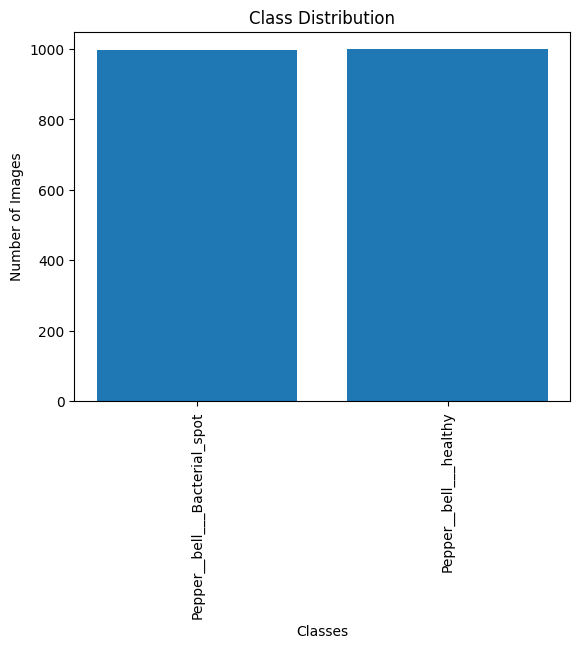

In [26]:
# Class Distribution
import os

class_count = []

for i in class_names:
    count = len(os.listdir(data_dir + "/" + i))
    class_count.append(count)

plt.bar(class_names, class_count)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.show()

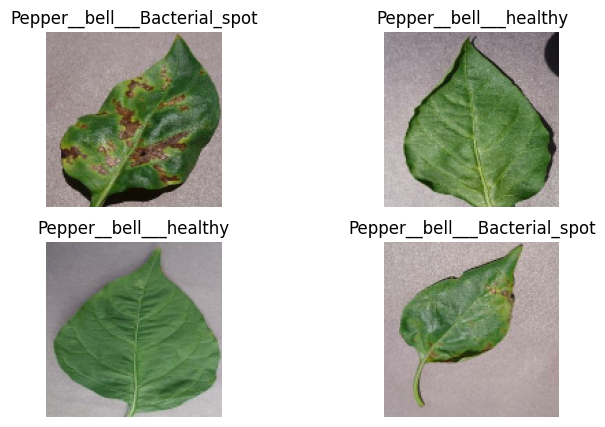

In [4]:
# DATA ANALYSIS
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for images, labels in train_ds.take(1):
    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [5]:
# NORMALIZATION
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


In [6]:
# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [8]:
# CNN Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128,128,3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [9]:
# COMPILE
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# TRAIN
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 721ms/step - accuracy: 0.5936 - loss: 0.7153 - val_accuracy: 0.5288 - val_loss: 0.6437
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 704ms/step - accuracy: 0.7984 - loss: 0.4727 - val_accuracy: 0.8195 - val_loss: 0.4037
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 712ms/step - accuracy: 0.8698 - loss: 0.3431 - val_accuracy: 0.7644 - val_loss: 0.5275
Epoch 4/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 708ms/step - accuracy: 0.8904 - loss: 0.3170 - val_accuracy: 0.9198 - val_loss: 0.2186
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 700ms/step - accuracy: 0.9042 - loss: 0.3006 - val_accuracy: 0.8095 - val_loss: 0.4459
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 701ms/step - accuracy: 0.9186 - loss: 0.2405 - val_accuracy: 0.9348 - val_loss: 0.1644
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 713ms/step - accuracy: 0.9411 - loss: 0.1797 - val_accuracy: 0.9449 - val_loss: 0.1525
Epoch 8/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 713ms/step - accuracy: 0.9468 - loss: 0.1505 - val_accuracy: 0.

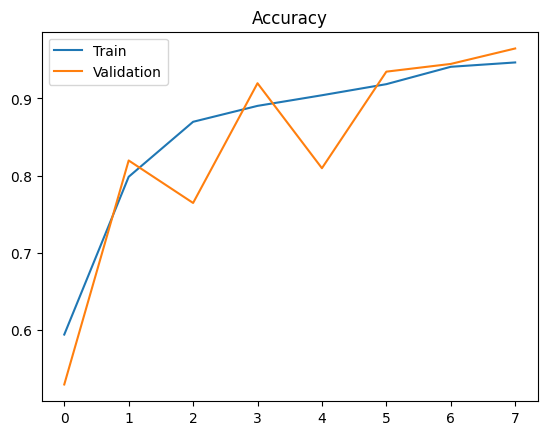

In [11]:
# GRAPHS
# Accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()


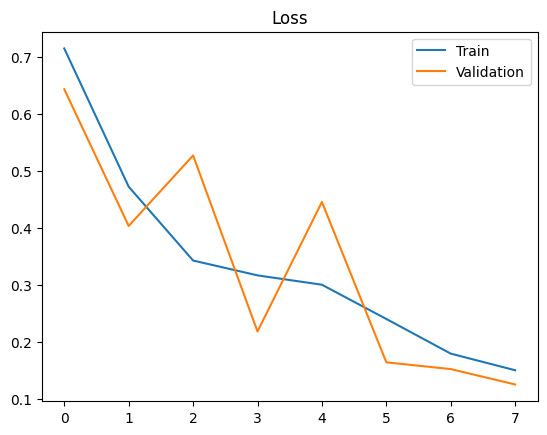

In [12]:
# Loss
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")
plt.show()

In [28]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Store actual and predicted values
y_true = []
y_pred = []

# Loop through validation data
for images, labels in val_ds:
    predictions = model.predict(images)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


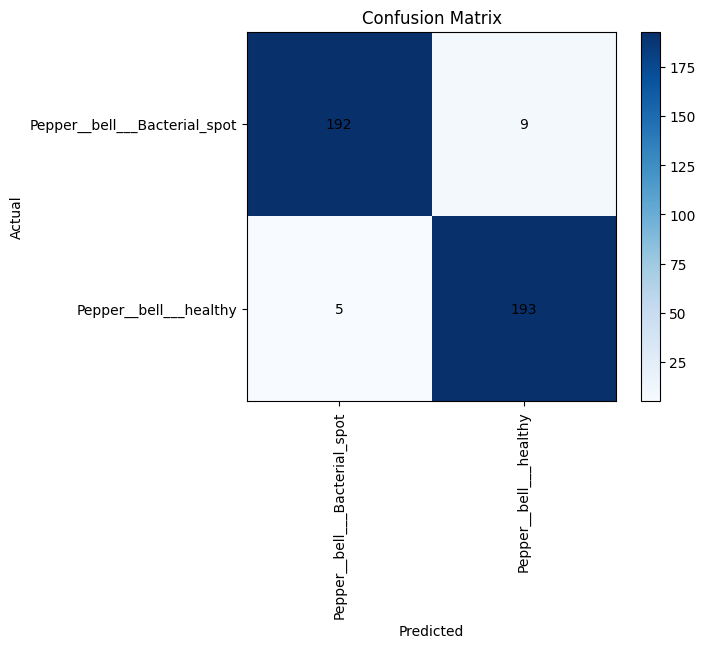

In [29]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add labels
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=90)
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)

# Show numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center', color='black')

plt.colorbar()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


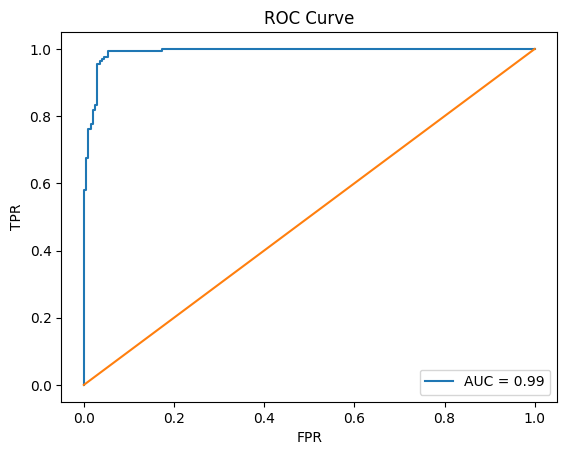

In [31]:
# ROC CURVE
from sklearn.metrics import roc_curve, auc

y_true = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)

    y_true.extend(labels.numpy())
    y_score.extend(preds[:, 1])

y_true = np.array(y_true)
y_score = np.array(y_score)

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1], [0,1])

plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.show()

In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [20]:
# Upload Image
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Selected Image:", img_path)

Saving Leaf image.jpg to Leaf image.jpg
Selected Image: Leaf image.jpg


In [21]:
# Preprocess Image
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)



In [22]:
# Predict Image
pred = model.predict(img_array)

predicted_class = class_names[np.argmax(pred)]
print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Class: Pepper__bell___Bacterial_spot


In [24]:
# Healthy vs Disease Result
if "healthy" in predicted_class.lower():
    print("Result: Healthy Leaf")
else:
    print("Result: Diseased Leaf")


# Suggestion System
def give_suggestion(label):

    label = label.lower()

    if "healthy" in label:
        print("Leaf is Healthy")
        print("Maintain proper watering")
        print("Ensure good sunlight")
        print("Use organic fertilizers")
        print("Monitor regularly")

    elif "bacterial" in label:
        print("Bacterial Disease")
        print("Use antibacterial spray")
        print("Avoid overwatering")
        print("Remove infected leaves")
        print("Improve drainage")

    elif "fungal" in label or "blight" in label:
        print("Fungal Disease")
        print("Apply fungicide")
        print("Avoid moisture on leaves")
        print("Increase air circulation")
        print("Remove affected parts")

    elif "virus" in label:
        print("Viral Disease")
        print("Remove infected plants")
        print("Control insects")
        print("Use resistant seeds")

    else:
        print("General Disease")
        print("Consult expert")
        print("Maintain soil health")
        print("Use balanced fertilizer")


# Call function
give_suggestion(predicted_class)

Result: Diseased Leaf
Bacterial Disease
Use antibacterial spray
Avoid overwatering
Remove infected leaves
Improve drainage


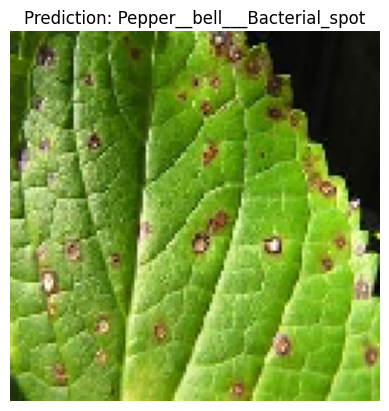

In [25]:
plt.imshow(img)
plt.title("Prediction: " + predicted_class)
plt.axis("off")
plt.show()